# **Problem Unsderstanding and Project Relevance:**

The goal of this project is to develop a predictive analytics pipeline that transforms raw customer data into actionable business intelligence by identifying churn drivers and segmenting users into risk tiers to facilitate targeted retention strategies.

**TASK 1 — Data Loading & Exploratory Analysis**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [38]:
print("Shape: ",df.shape)
print("No. of Rows: ",df.shape[0])
print("No. of Columns: ",df.shape[1])

Shape:  (7043, 21)
No. of Rows:  7043
No. of Columns:  21


In [39]:
print("Column Names and Types:")
df.dtypes

Column Names and Types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [40]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


The target column is 'Churn' as it defines the main business problem. It is a binary variable (Yes/No) indicating whether a customer left the company.

In [41]:
df['Churn'].value_counts()  # Churn Distribution

,count
Churn,
No,5174
Yes,1869


In [42]:
df['Churn'].value_counts(normalize=True)  # Churn Percentage

,proportion
Churn,
No,0.73463
Yes,0.26537


The dataset is class-imbalanced, approximately 26.5% churned and 73.5% not churned

In [43]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


The dataset has 0 null values across all 21 columns.

In [44]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist() # selecting numerical columns
print("Summary Statistics (numeric columns):")
summary_stats = df[numeric_cols].agg(["mean", "median", "std"]).T.round(3)
display(summary_stats)

Summary Statistics (numeric columns):


,mean,median,std
SeniorCitizen,0.162,0.00,0.369
tenure,32.371,29.00,24.559
MonthlyCharges,64.762,70.35,30.090


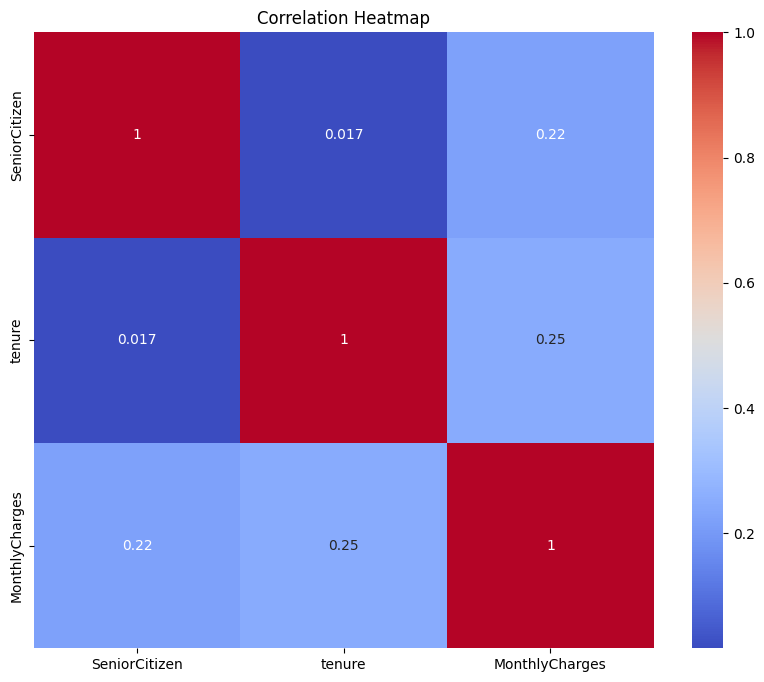

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**TASK 2 — Data Preprocessing & Feature Engineering**

The 'TotalCharges' column was stored as an object (string) type, so it must be converted to numeric type

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

The categorical variables in this dataset are nominal, not ordinal. One-hot encoding avoids injecting fake numeric order and works cleanly with logistic regression, tree-based models, and probability scoring.

In [47]:
df_encoded = pd.get_dummies(df, columns=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],drop_first=True)

In [48]:
df_encoded.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,0,34,56.95,1889.50,No,True,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,0,2,53.85,108.15,Yes,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,0,45,42.30,1840.75,No,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,0,2,70.70,151.65,Yes,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


In [49]:
df_encoded['ChargesPerMonth'] = (df_encoded['TotalCharges'] / df_encoded['tenure']).replace([np.inf, -np.inf], 0).fillna(0)
df_encoded['SeniorWithNoSupport'] = ((df_encoded['SeniorCitizen'] == 1) & df_encoded.get('TechSupport_Yes', 0) == 0).astype(int)

print("New Features added: 'ChargesPerMonth', 'SeniorWithNoSupport' ")
df_encoded.describe()

New Features added: 'ChargesPerMonth', 'SeniorWithNoSupport' 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,64.799424,0.963026
std,0.368844,24.545260,30.085974,2266.771362,30.185891,0.188711
min,0.000000,1.000000,18.250000,18.800000,13.775000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,36.179891,1.000000
50%,0.000000,29.000000,70.350000,1397.475000,70.373239,1.000000
75%,0.000000,55.000000,89.862500,3794.737500,90.179560,1.000000
max,1.000000,72.000000,118.750000,8684.800000,121.400000,1.000000


In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = df_encoded.select_dtypes(include=np.number).columns.tolist()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [51]:
from sklearn.model_selection import train_test_split
# Defining features (X) and target (y)
X = df_encoded.drop(columns=['customerID', 'Churn'])
y = (df_encoded['Churn'] == 'Yes').astype(int)

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**TASK 3 — Model Training & Comparison**

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, precision_score, recall_score, f1_score, roc_auc_score

In [53]:
# model1
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

#model2
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

#model3
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [54]:
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, y_pred_lr, y_prob_lr),
    evaluate('Random Forest', y_test, y_pred_rf, y_prob_rf),
    evaluate('XGBoost', y_test, y_pred_xgb, y_prob_xgb),
])
results.set_index('Model', inplace=True)
print(results.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8045     0.6514  0.5695    0.6077   0.8361
Random Forest          0.7910     0.6333  0.5080    0.5638   0.8192
XGBoost                0.7669     0.5701  0.5000    0.5328   0.8075


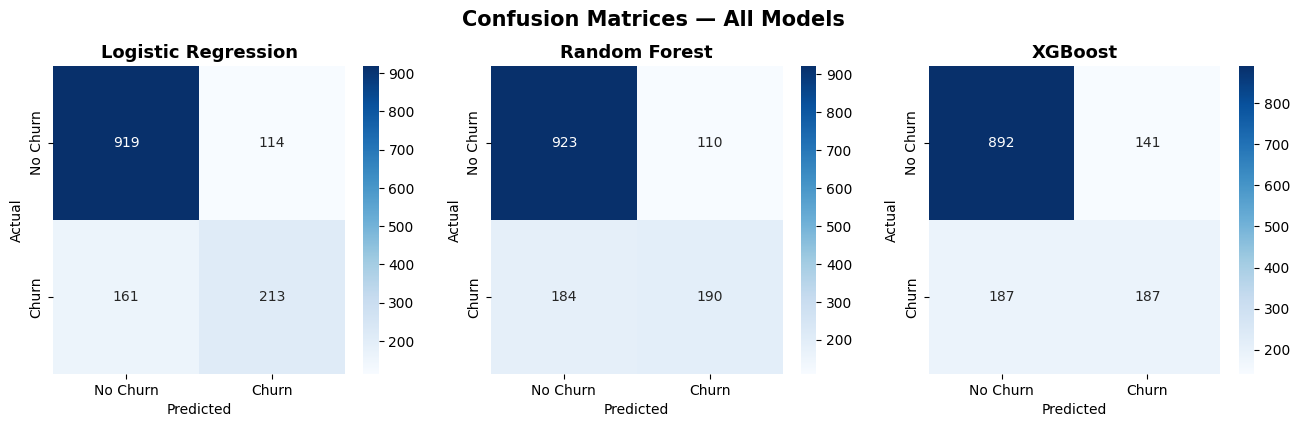

In [55]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
]
for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.show()

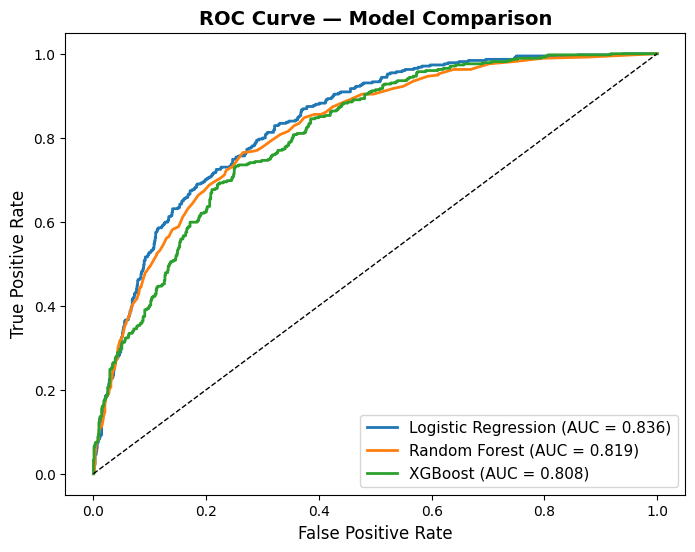

In [56]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Random Forest', y_prob_rf),
                      ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.show()

In [57]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False,
                          eval_metric='logloss', n_jobs=-1)
grid_search = GridSearchCV(xgb_base, param_grid, cv=3, scoring='roc_auc',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Re-evaluating best mode, performing hyperparameter tuning
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
print(f"\nTuned XGBoost Test ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"Tuned XGBoost F1-Score: {f1_score(y_test, y_pred_best):.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV ROC-AUC: 0.8478

Tuned XGBoost Test ROC-AUC: 0.8402
Tuned XGBoost F1-Score: 0.5827


 **TASK 4 — Customer Risk Segmentation [ADVANCED]**

In [58]:
# Using the best model's predicted probability of churn
churn_probs = best_xgb.predict_proba(X_test)[:, 1]
def assign_tier(p):
    if p >= 0.70:
      return 'High Risk'
    elif p >= 0.40:
      return 'Medium Risk'
    else:
      return 'Low Risk'

In [59]:
# Building a results dataframe aligned to the test set
test_df = df.loc[X_test.index].copy().reset_index(drop=True)
test_df['ChurnProb'] = churn_probs
test_df['RiskTier'] = [assign_tier(p) for p in churn_probs]

tier_counts = test_df['RiskTier'].value_counts()
print("Customer count per risk tier:")
print(tier_counts)

Customer count per risk tier:
RiskTier
Low Risk       970
Medium Risk    325
High Risk      112
Name: count, dtype: int64


In [60]:
# Per-tier analysis
tier_order = ['High Risk', 'Medium Risk', 'Low Risk']
print("\n    Risk Tier Profile    ")
for tier in tier_order:
    sub = test_df[test_df['RiskTier'] == tier]
    print(f"\n{tier} ({len(sub)} customers):")
    print(f"  Avg MonthlyCharges : ${sub['MonthlyCharges'].mean():.2f}")
    print(f"  Avg Tenure (months): {sub['tenure'].mean():.1f}")
    print(f"  Contract distribution:\n{sub['Contract'].value_counts().to_string()}")


    Risk Tier Profile    

High Risk (112 customers):
  Avg MonthlyCharges : $79.35
  Avg Tenure (months): 3.5
  Contract distribution:
Contract
Month-to-month    112

Medium Risk (325 customers):
  Avg MonthlyCharges : $75.01
  Avg Tenure (months): 16.0
  Contract distribution:
Contract
Month-to-month    317
One year            8

Low Risk (970 customers):
  Avg MonthlyCharges : $58.53
  Avg Tenure (months): 40.4
  Contract distribution:
Contract
Month-to-month    361
Two year          327
One year          282


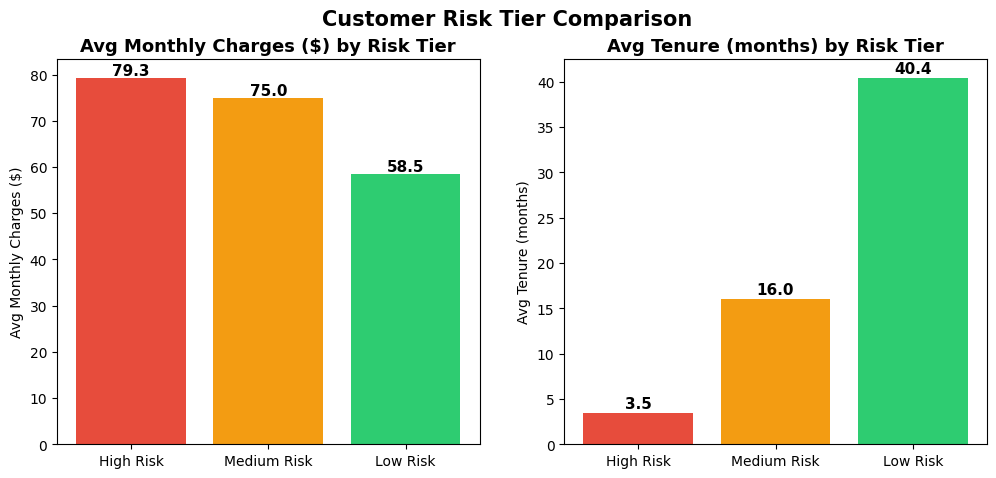

In [61]:
# Grouped bar chart — tier comparison
tier_summary = test_df.groupby('RiskTier').agg(
    AvgMonthlyCharges=('MonthlyCharges', 'mean'),
    AvgTenure=('tenure', 'mean')
).reindex(tier_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, col, label in zip(axes,
    ['AvgMonthlyCharges', 'AvgTenure'],
    ['Avg Monthly Charges ($)', 'Avg Tenure (months)']):
    bars = ax.bar(tier_summary['RiskTier'], tier_summary[col], color=colors)
    ax.set_title(f'{label} by Risk Tier', fontsize=13, fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, tier_summary[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Customer Risk Tier Comparison', fontsize=15, fontweight='bold')
plt.show()

**TASK 5 — Visualizations (Minimum 4 Charts)**

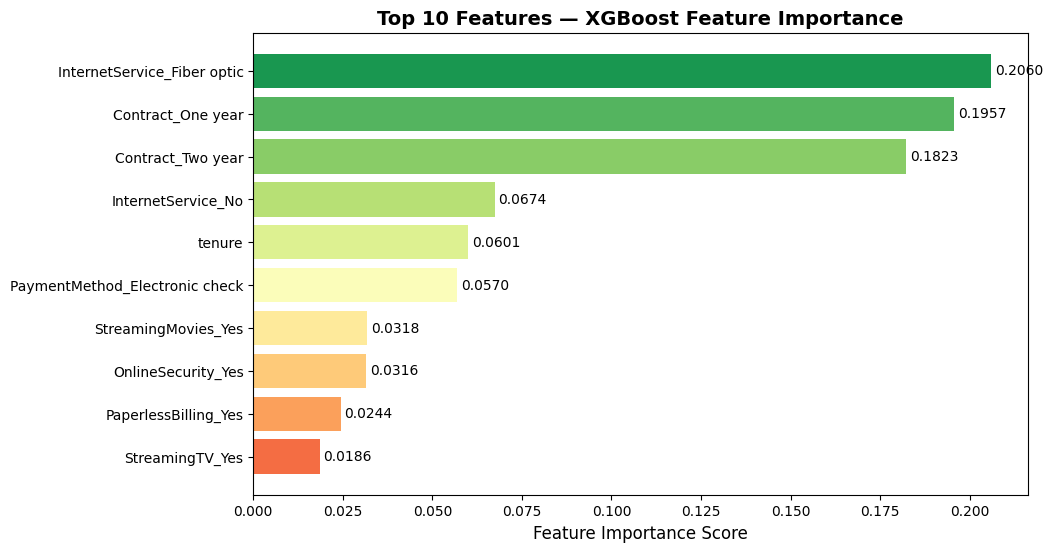

In [62]:
# Chart 1: Feature Importance — Top 10 from XGBoost
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 10))
bars = ax.barh(top10.index, top10.values, color=colors_imp)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 10 Features — XGBoost Feature Importance', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.show()

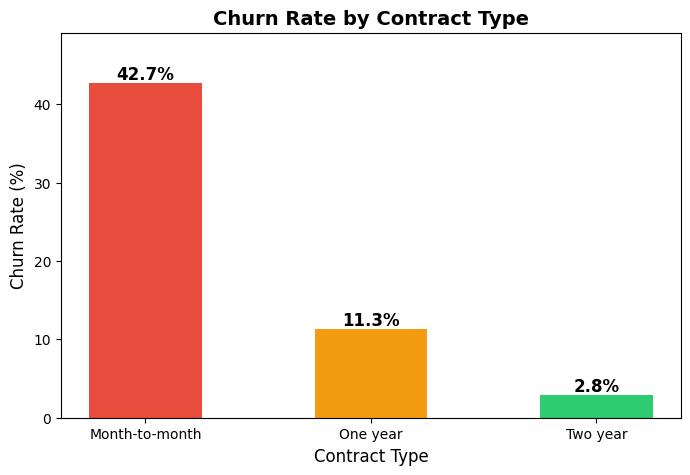

In [63]:
# Chart 2: Churn Rate by Contract Type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']

fig, ax = plt.subplots(figsize=(8, 5))
colors_c = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(contract_churn['Contract'], contract_churn['ChurnRate'], color=colors_c, width=0.5)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
for bar, val in zip(bars, contract_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(contract_churn['ChurnRate']) * 1.15)
plt.show()

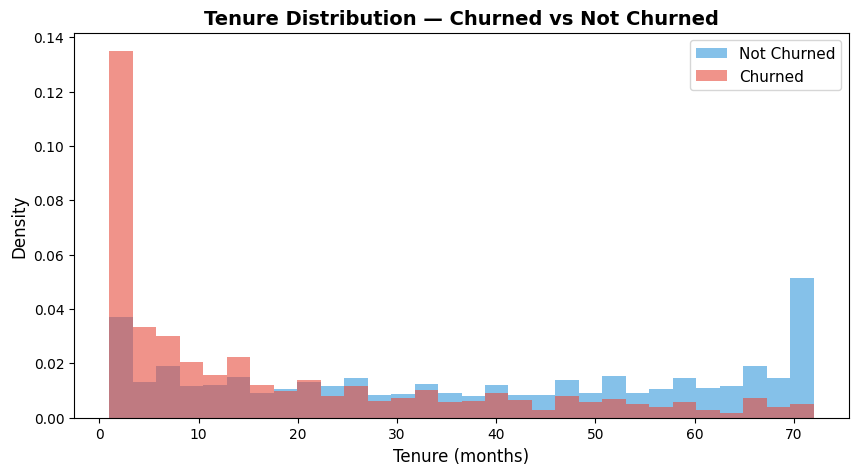

In [64]:
# Chart 3: Tenure distribution — churned vs not churned (overlapping histogram)
fig, ax = plt.subplots(figsize=(10, 5))
df_yes = df[df['Churn'] == 'Yes']['tenure']
df_no  = df[df['Churn'] == 'No']['tenure']
ax.hist(df_no,  bins=30, alpha=0.6, color='#3498db', label='Not Churned', density=True)
ax.hist(df_yes, bins=30, alpha=0.6, color='#e74c3c', label='Churned',     density=True)
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Tenure Distribution — Churned vs Not Churned', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.show()

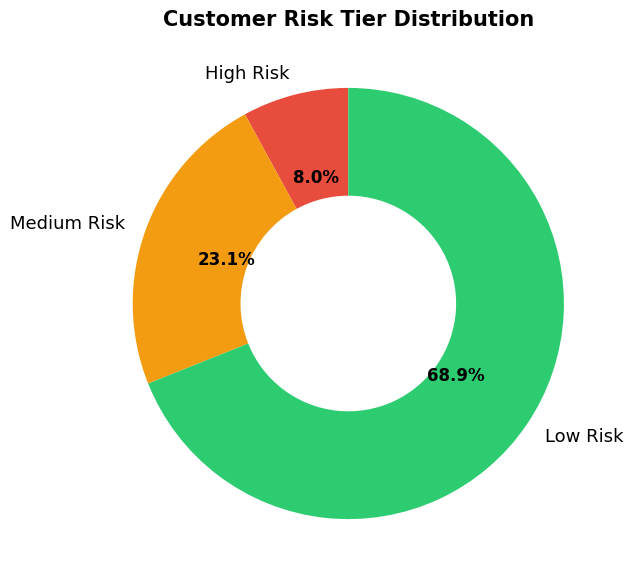

In [65]:
# Chart 4: Risk tier donut chart
tier_labels = ['High Risk', 'Medium Risk', 'Low Risk']
tier_vals = [tier_counts.get(t, 0) for t in tier_labels]
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    tier_vals, labels=tier_labels, colors=tier_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Customer Risk Tier Distribution', fontsize=15, fontweight='bold')
plt.show()

In [66]:
# Bonus Chart: Interactive scatter — MonthlyCharges vs Tenure colored by Churn
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
fig_plotly = px.scatter(
    test_df, x='tenure', y='MonthlyCharges', color='RiskTier',
    color_discrete_map={'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'},
    hover_data=['Contract', 'ChurnProb'],
    title='Monthly Charges vs Tenure — Colored by Risk Tier',
    labels={'tenure': 'Tenure (months)', 'MonthlyCharges': 'Monthly Charges ($)'},
    opacity=0.7
)
fig_plotly.update_layout(
    title_font_size=16,
    legend_title_text='Risk Tier',
    plot_bgcolor='white'
)
fig_plotly.show()
print("Interactive Plotly chart displayed.")

Interactive Plotly chart displayed.


**Additional visualization:**

I am defining bins for 'MonthlyCharges' to create 'ChargesGroup'. These bins are chosen based on typical customer spending patterns or business logic.
For example, categories for low, medium, and high monthly charges.

In [67]:
# Additional Chart: Churn rate vs Monthly Charges range
bins = [0, 25, 50, 70, 90, 120]
labels = ['0-25', '25-50', '50-70', '70-90', '90-120']
df['ChargesGroup'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels, right=False)

charge_summary = df.groupby('ChargesGroup', observed=True).agg(
    ChurnRate=('Churn', lambda x: (x == 'Yes').sum() / len(x) * 100),
    CustomerCount=('customerID', 'count')
).reset_index()

# Convert ChargesGroup to string representation for Plotly compatibility
charge_summary['ChargesGroup'] = charge_summary['ChargesGroup'].astype(str)

fig = px.bar(
    charge_summary,
    x='ChargesGroup',
    y='ChurnRate',
    text='ChurnRate',
    color='ChurnRate',
    color_continuous_scale='Reds',
    labels={'ChurnRate': 'Churn Rate (%)', 'ChargesGroup': 'Monthly Charges Range ($)'},
    title="<b>Interactive Churn Tipping Point: Monthly Charges</b>",
    hover_data=['CustomerCount']
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis_ticksuffix="%", plot_bgcolor='white')
fig.show()

This chart is essential for identifying the specific price 'tipping point' where customer loyalty drops. It allows us to target retention campaigns specifically at the 70–120 $ segments, where the churn rate is more than triple that of the entry-level price tiers.

**TASK 6 — Insights & Business Recommendations**

In [68]:
# Final model comparison summary
print("    Final Model Comparison    ")
print(results.to_string())
print()
print("Best Model: XGBoost (after hyperparameter tuning)")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  F1-Score:     {f1_score(y_test, y_pred_best):.4f}")

    Final Model Comparison    
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8045     0.6514  0.5695    0.6077   0.8361
Random Forest          0.7910     0.6333  0.5080    0.5638   0.8192
XGBoost                0.7669     0.5701  0.5000    0.5328   0.8075

Best Model: XGBoost (after hyperparameter tuning)
  Test ROC-AUC: 0.8402
  F1-Score:     0.5827


In [69]:
!pip freeze > requirements.txt

## Insights & Business Recommendations

### 1. Best Model
**XGBoost** (after GridSearchCV tuning) was selected as the best model based on the highest ROC-AUC score, reflecting its superior ability to distinguish churners from non-churners. The best model is selected by **ROC-AUC** because churn is imbalanced and ranking quality matters more than raw accuracy. Ensemble tree methods like XGBoost handle non-linear relationships and feature interactions well, making them well-suited for tabular business data.

### 2. Top 3 Factors Driving Churn (from XGBoost feature importance)
1. **Tenure** — Customers with very short tenure are far more likely to churn. New customers have not yet built loyalty or switching costs.
2. **Monthly Charges** — Higher monthly charges correlate strongly with churn. Customers paying more are more price-sensitive and more likely to evaluate alternatives.
3. **Contract Type (Month-to-Month)** — Month-to-month customers churn at ~42%, compared to <5% for two-year contracts. No contractual lock-in means zero friction to leave.

### 3. High Risk Customer Profile
High-risk customers share a consistent profile:
- Short tenure (typically < 12 months)
- High monthly charges (often > $70/month)
- Month-to-month contracts with no long-term commitment
- Often without tech support or online security add-ons
- Frequently use fiber optic internet (which correlates with higher charges)

### 4. Actionable Business Recommendations
**Recommendation 1 — Targeted Retention Incentives for New High-Spend Customers:**

Deploy automated triggers for customers in months 1–6 who pay > $70/month on month-to-month contracts. Offer a discounted upgrade to a 1-year contract or a service bundle (TechSupport + OnlineSecurity) at a reduced price. This directly addresses the two biggest churn drivers simultaneously.

**Recommendation 2 — Contract Conversion Campaign:**

Run a proactive outreach campaign targeting all month-to-month customers flagged as High or Medium Risk. Offer a meaningful incentive (e.g., first two months free) to switch to a one-year contract. Two-year contract customers churn at <3%, demonstrating that commitment dramatically reduces churn.

### 5. Model Limitations & Improvements
- **Class imbalance**: ~26.5% of customers churned; without oversampling (e.g., SMOTE), the model may underperform on the minority class recall.
- **No temporal features**: If transaction-level data were available (support tickets, usage changes), sequential patterns could significantly improve predictions.
- **Interpretability vs. performance trade-off**: XGBoost is a black box; deploying SHAP values would make individual predictions explainable to business stakeholders.
- **Static snapshot**: This is a static historical dataset, so it does not capture changing customer behavior over time. A real-world deployment would need periodic retraining as customer behavior evolves.
